In [1]:
import pandas as pd

In [3]:
data = pd.read_csv('financial data_training.csv')

In [5]:
data.head()

,y1,y3
0,3.24,3.70
1,3.32,3.75
2,3.29,3.80
3,3.26,3.77
4,3.29,3.80


In [15]:
data_cleaned = data.groupby('y1', as_index=False).agg({'y3': 'mean'})


In [17]:
data_cleaned

,y1,y3
0,2.91,3.340
1,2.96,3.350
2,2.97,3.350
3,2.98,3.348
4,2.99,3.372
...,...,...
792,16.63,15.360
793,16.74,15.980
794,16.93,16.420
795,17.07,16.390


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

In [25]:
X = data_cleaned[['y1']]  # 自變數
y = data_cleaned['y3']

In [27]:
model = LinearRegression()

In [28]:
cv_score = cross_val_score(model, X, y, cv=10, scoring = 'neg_mean_squared_error')
rmse_score = np.sqrt(-cv_score)

In [30]:
# 輸出交叉驗證結果
print(f"Mean RMSE: {rmse_score.mean():.4f}")
print(f"Standard Deviation of RMSE: {rmse_score.std():.4f}")

Mean RMSE: 0.4944
Standard Deviation of RMSE: 0.2284


In [33]:
model.fit(X, y)
new_data = pd.DataFrame({'y1':[2.91]})
predicted_y3 = model.predict(new_data)
new_data['Pred_y3'] = predicted_y3
new_data

,y1,Pred_y3
0,2.91,3.653292


In [37]:
# 重新載入必要套件並重新讀取資料
import pandas as pd
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import numpy as np
from factor_analyzer import FactorAnalyzer

# 重新讀取數據
file_path = 'SanYi_training.csv'
data = pd.read_csv(file_path)

# 查看資料基本資訊
data_info = data.describe()
data_info


,PM25,PM10,CO,NO,NO2,NOx,O3,PH_RAIN,RAINFALL,RH,SO2,TEMP,UVB,WIND_DIREC,WIND_SPEED
count,43752.000000,43747.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000,43752.000000
mean,27.431249,47.445685,0.319926,2.028926,11.632555,13.668853,32.940491,0.286560,0.282762,81.311551,2.703550,20.889199,1.524836,110.404554,3.242178
std,19.120461,31.120988,0.140045,2.903157,6.397724,7.995039,19.520381,1.139614,2.142172,12.398401,1.605656,5.666470,2.553305,87.808672,2.020281
min,0.000000,0.000000,0.050000,-0.290000,0.150000,0.380000,0.100000,0.000000,0.000000,0.160000,0.000000,3.270000,0.000000,0.070000,0.020000
25%,13.000000,26.000000,0.220000,0.710000,7.120000,8.350000,19.000000,0.000000,0.000000,73.660000,1.700000,16.590000,0.000000,37.353750,1.690000
50%,23.000000,42.000000,0.300000,1.250000,10.430000,11.960000,29.500000,0.000000,0.000000,83.960000,2.250000,21.860000,0.100000,54.640000,2.900000
75%,38.000000,62.000000,0.400000,2.170000,14.800000,16.980000,42.800000,0.000000,0.000000,90.560000,3.300000,25.130000,2.100000,192.032500,4.400000
max,240.000000,694.000000,1.320000,64.090000,63.550000,93.200000,156.800000,7.830000,117.800000,99.660000,90.400000,35.070000,14.400000,360.000000,17.030000


KMO Test: 0.656
Bartlett's Test: Chi-Square=430332.255, p-value=0.000


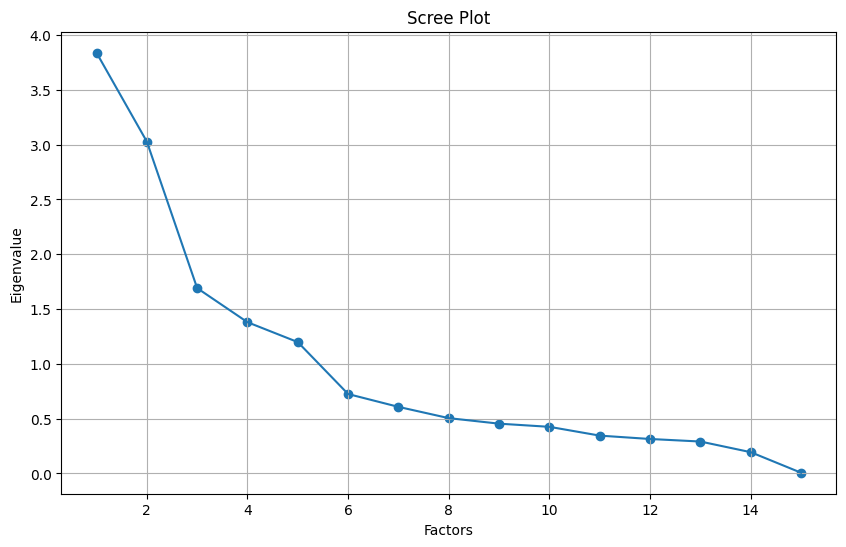

Factor Loadings (Varimax Rotation):
             Factor1   Factor2   Factor3
PM25        0.716478  0.050955 -0.065505
PM10        0.797087  0.085289 -0.014880
CO          0.684301  0.409656 -0.325878
NO          0.047004  0.610816  0.053074
NO2         0.476710  0.711040 -0.270858
NOx         0.392084  0.908901 -0.170366
O3          0.476314 -0.465647  0.452853
PH_RAIN    -0.224691 -0.023842 -0.068054
RAINFALL   -0.167202 -0.048833 -0.033364
RH         -0.379818  0.236702 -0.647887
SO2         0.591287  0.101642  0.191980
TEMP       -0.070480  0.072777  0.770902
UVB         0.212383 -0.154615  0.635031
WIND_DIREC -0.068529  0.127145  0.489664
WIND_SPEED -0.026752 -0.341213 -0.066446


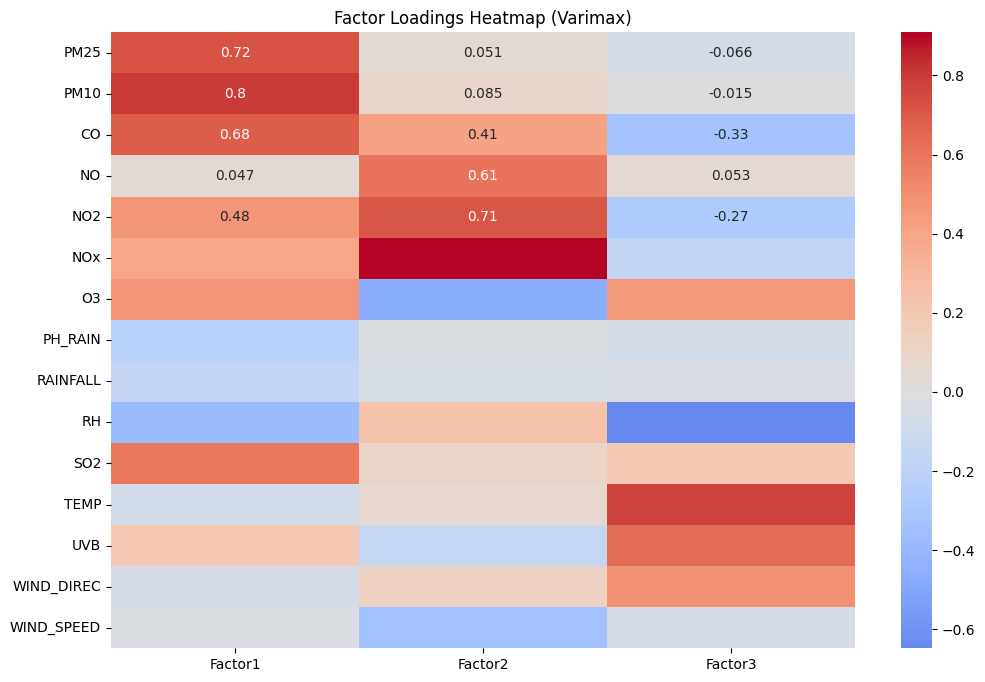

In [39]:
# 匯入必要套件
import matplotlib.pyplot as plt

# 進行資料預處理，去除缺失值
clean_data = data.dropna()

# 標準化數據
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clean_data)

# 適合性檢驗 (KMO 和 Bartlett's Test)
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

kmo_all, kmo_model = calculate_kmo(scaled_data)
chi_square_value, p_value = calculate_bartlett_sphericity(scaled_data)
print(f"KMO Test: {kmo_model:.3f}")
print(f"Bartlett's Test: Chi-Square={chi_square_value:.3f}, p-value={p_value:.3f}")

# 因子分析，確定因子數量
fa = FactorAnalyzer(rotation=None)
fa.fit(scaled_data)

eigen_values, vectors = fa.get_eigenvalues()

# 繪製碎石圖 (Scree Plot)
plt.figure(figsize=(10, 6))
plt.scatter(range(1, len(eigen_values)+1), eigen_values)
plt.plot(range(1, len(eigen_values)+1), eigen_values)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

# 選擇合適的因子數並執行 Varimax 旋轉
n_factors = 3  # 假設選擇3個因子
fa = FactorAnalyzer(rotation='varimax', n_factors=n_factors)
fa.fit(scaled_data)

# 獲取因子負荷矩陣
factor_loadings = fa.loadings_

# 將因子負荷矩陣轉換為 DataFrame
loadings_df = pd.DataFrame(factor_loadings, index=clean_data.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])

# 輸出因子負荷矩陣
print("Factor Loadings (Varimax Rotation):")
print(loadings_df)

# 可視化因子負荷
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap (Varimax)')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_25280\2119858568.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['PM10'].fillna(method='ffill', inplace=True)



PM25 欄位的平穩性檢驗結果:
ADF 檢驗統計量: -17.496164864154895
p 值: 4.410269265090121e-30
使用的滯後數: 50
觀測值數量: 43701
臨界值 1%: -3.430499646098528
臨界值 5%: -2.861606140292136
臨界值 10%: -2.566805204326622
數據沒有單位根，為平穩序列

PM10 欄位的平穩性檢驗結果:
ADF 檢驗統計量: -17.60410156855514
p 值: 3.9083987880211344e-30
使用的滯後數: 55
觀測值數量: 43696
臨界值 1%: -3.430499663223081
臨界值 5%: -2.8616061478606216
臨界值 10%: -2.566805208355114
數據沒有單位根，為平穩序列

CO 欄位的平穩性檢驗結果:
ADF 檢驗統計量: -14.524172973110394
p 值: 5.462635011875528e-27
使用的滯後數: 55
觀測值數量: 43696
臨界值 1%: -3.430499663223081
臨界值 5%: -2.8616061478606216
臨界值 10%: -2.566805208355114
數據沒有單位根，為平穩序列

NO 欄位的平穩性檢驗結果:
ADF 檢驗統計量: -22.635186302641344
p 值: 0.0
使用的滯後數: 54
觀測值數量: 43697
臨界值 1%: -3.430499659797857
臨界值 5%: -2.861606146346786
臨界值 10%: -2.5668052075493417
數據沒有單位根，為平穩序列

NO2 欄位的平穩性檢驗結果:
ADF 檢驗統計量: -17.207662962719127
p 值: 6.399094784450772e-30
使用的滯後數: 53
觀測值數量: 43698
臨界值 1%: -3.4304996563727896
臨界值 5%: -2.8616061448330194
臨界值 10%: -2.5668052067436067
數據沒有單位根，為平穩序列

NOx 欄位的平穩性檢驗結果:
ADF 檢驗統計量: -18.73974

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


最佳滯後階數: {'aic': 49, 'bic': 24, 'hqic': 25, 'fpe': 49}


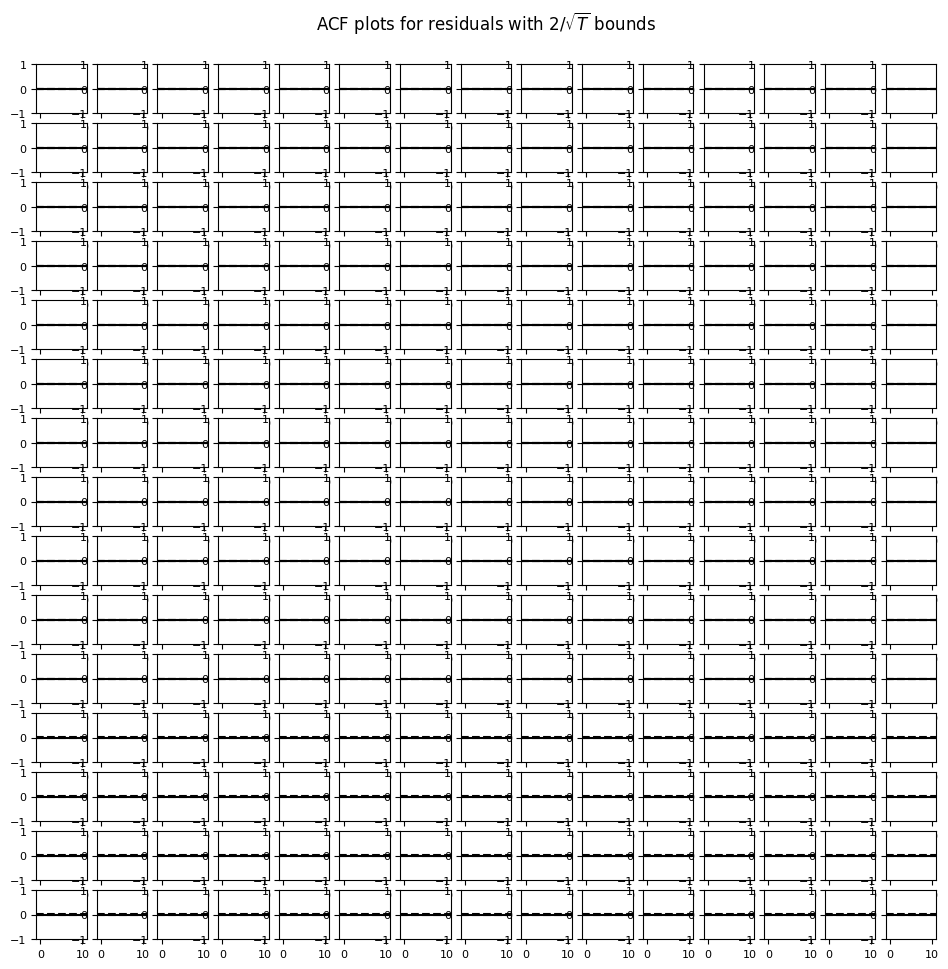

                                    PM25       PM10        CO        NO  \
1970-01-01 00:00:00.000043751  17.513860  99.847121  0.325392  1.578225   
1970-01-01 01:00:00.000043751  18.737664  99.795507  0.331375  1.964580   
1970-01-01 02:00:00.000043751  20.646045  93.508994  0.323182  1.765864   
1970-01-01 03:00:00.000043751  20.194898  87.755190  0.279910  0.322940   
1970-01-01 04:00:00.000043751  18.365121  86.877024  0.266447  0.826655   
1970-01-01 05:00:00.000043751  18.038759  84.413025  0.266384  1.854649   
1970-01-01 06:00:00.000043751  19.608439  81.444297  0.280372  1.740124   
1970-01-01 07:00:00.000043751  20.627956  79.730086  0.252175  1.574936   
1970-01-01 08:00:00.000043751  18.907009  78.567192  0.270578  1.786887   
1970-01-01 09:00:00.000043751  18.396218  80.366808  0.298733  2.984929   

                                     NO2        NOx         O3   PH_RAIN  \
1970-01-01 00:00:00.000043751  13.930096  16.082594  32.526753  0.165334   
1970-01-01 01:00:00.00

In [41]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# 讀取數據
data = pd.read_csv('SanYi_training.csv')

# 缺失值處理
data['PM10'].fillna(method='ffill', inplace=True)

# 平穩性檢驗函數
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'ADF 檢驗統計量: {result[0]}')
    print(f'p 值: {result[1]}')
    print(f'使用的滯後數: {result[2]}')
    print(f'觀測值數量: {result[3]}')
    for key, value in result[4].items():
        print(f'臨界值 {key}: {value}')
    if result[1] <= 0.05:
        print("數據沒有單位根，為平穩序列")
    else:
        print("數據存在單位根，為非平穩序列")

# 對每個欄位進行平穩性檢驗
for column in data.columns:
    print(f'\n{column} 欄位的平穩性檢驗結果:')
    adf_test(data[column])

# 對非平穩序列進行差分
data_diff = data.diff().dropna()

# 選擇最佳滯後階數
model = VAR(data_diff)
lag_order = model.select_order()
print(f'最佳滯後階數: {lag_order.selected_orders}')

# 擬合 VAR 模型
model_fitted = model.fit(lag_order.selected_orders['aic'])

# 模型診斷：殘差檢查
model_fitted.plot_acorr()
plt.show()

# 預測
forecast_input = data_diff.values[-lag_order.selected_orders['aic']:]
forecast = model_fitted.forecast(y=forecast_input, steps=10)
forecast_df = pd.DataFrame(forecast, index=pd.date_range(start=data.index[-1], periods=10, freq='H'), columns=data.columns)

# 反差分以獲得實際預測值
def invert_transformation(df_train, df_forecast):
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:
        df_fc[col] = df_train[col].iloc[-1] + df_fc[col].cumsum()
    return df_fc

forecast_real = invert_transformation(data, forecast_df)

# 顯示預測結果
print(forecast_real)
